# Same-Phase vs. Independent-White Noise Floor — Sampling & Spectrum Intuition

Companion notebook for the two proposed initial-noise methods from `noise_init/README.md`,
implemented in `noise_init/noise_methods.py`. Both start from a pink-shaped base signal
$z_{\text{pink}}(\alpha)$ and raise its noise floor by mixing in a $\gamma$-weighted
white-noise component, but they differ in *where* that white component comes from:

- **Same-phase floor**: reshapes the spectral envelope of $z_{\text{white}}$ itself, so the
  output keeps $z_{\text{white}}$'s own Fourier phase at every $\gamma$.
- **Independent-white floor**: mixes an independent white-noise draw $\eta$ with
  $z_{\text{pink}}(\alpha)$ in the *spatial* domain, so it does not share $z_{\text{white}}$'s
  phase once $\gamma > 0$.

All sampling code below is written out in this notebook (not imported) so it can be
checked line-by-line against `noise_init/noise_methods.py`; each function's docstring
names the mirrored source function.

## Formulas (from `noise_init/README.md` and `noise_methods.py`)

Radial spatial frequency uses DivGen-compatible integer FFT-bin coordinates:

$$
f_y = \operatorname{fftfreq}(H) \cdot H, \qquad
f_x = \operatorname{rfftfreq}(W) \cdot W, \qquad
r = \sqrt{f_y^2 + f_x^2}
$$

Pink amplitude filter (expected PSD $\propto (1+r)^{-2\alpha}$):

$$
h(r) = (1 + r)^{-\alpha}
$$

Baseline pink noise ($\alpha=0$ bypasses the FFT round trip entirely and is an *exact*
alias of $z_{\text{white}}$):

$$
z_{\text{pink}} = \mathrm{IFFT}_{2D}\big( \mathrm{FFT}_{2D}(z_{\text{white}}) \cdot h(r) \big)
$$

**Same-phase floor** ($\gamma \in [0, 1]$):

$$
m_{\text{same}}(r) = \sqrt{(1 - \gamma)\, h(r)^2 + \gamma}
\qquad\qquad
z_{\text{same phase}} = \mathrm{IFFT}_{2D}\big( \mathrm{FFT}_{2D}(z_{\text{white}}) \cdot m_{\text{same}}(r) \big)
$$

At $\gamma=1$ (or $\alpha=0$) this is an *exact* alias of $z_{\text{white}}$ — same phase,
and the floor term swallows the whole spectrum.

**Independent-white floor** ($\gamma \in [0, 1]$, independent draw $\eta$):

$$
z_{\text{indi white}} = \sqrt{1 - \gamma}\; z_{\text{pink}}(\alpha) + \sqrt{\gamma}\; \eta
$$

At $\gamma=0$ this is exactly $z_{\text{pink}}(\alpha)$; at $\gamma=1$ it is exactly $\eta$
— a *fresh* white-noise draw, not $z_{\text{white}}$ itself.

Both methods share the same **expected radial PSD**:

$$
\mathrm{shape}(r) = (1 - \gamma)\, h(r)^2 + \gamma
$$

so a purely spectral comparison cannot tell them apart — the actual difference is phase
coherence with the underlying pink signal, which section 4 below measures directly.

Note: latent channels are shown directly as pseudo-RGB for visual intuition; these are raw
noise tensors, not VAE-decoded images.

In [1]:
import numpy as np
import torch
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

SEED = 42
H, W, C = 128, 128, 3
ALPHA = 0.9  # fixed pink exponent for the gamma sweep below (mid-range of noise_init's 0.6-0.9 alpha grid)
GAMMAS = [0.0125,0.025, 0.05, 0.075, 0.1]  # matches the [0, 0.1] gamma range used by both proposed methods


def radial_frequency_grid(height, width):
    '''Radial frequency in DivGen's integer FFT-bin index units.
    Mirrors noise_init/noise_methods.py::radial_frequency_grid.'''
    fy = torch.fft.fftfreq(height).view(height, 1) * height
    fx = torch.fft.rfftfreq(width).view(1, width // 2 + 1) * width
    return torch.sqrt(fy.square() + fx.square())


def pink_filter(height, width, alpha):
    '''h(r) = (1 + r)^(-alpha). Mirrors noise_methods.py::pink_filter.'''
    if alpha < 0:
        raise ValueError("alpha must be non-negative")
    return (1.0 + radial_frequency_grid(height, width)).pow(-float(alpha))


def pink(base_white, alpha):
    '''z_pink = IFFT2D(FFT2D(z_white) * h(r)). Mirrors noise_methods.py::pink.
    alpha=0 bypasses FFT/IFFT so it stays an exact reference to base_white.'''
    if alpha == 0.0:
        return base_white.clone()
    multiplier = pink_filter(base_white.shape[-2], base_white.shape[-1], alpha)
    return torch.fft.irfft2(torch.fft.rfft2(base_white, dim=(-2, -1)) * multiplier,
                             s=base_white.shape[-2:], dim=(-2, -1))


def same_phase_floor(base_white, alpha, gamma):
    '''m_same(r) = sqrt((1-gamma) h(r)^2 + gamma), applied to FFT(z_white) itself so the
    output keeps z_white's Fourier phase exactly. Mirrors noise_methods.py::same_phase_floor.'''
    if not 0.0 <= gamma <= 1.0:
        raise ValueError("gamma must lie in [0, 1]")
    if alpha == 0.0 or gamma == 1.0:
        return base_white.clone()
    h = pink_filter(base_white.shape[-2], base_white.shape[-1], alpha)
    multiplier = torch.sqrt((1.0 - gamma) * h.square() + gamma)
    return torch.fft.irfft2(torch.fft.rfft2(base_white, dim=(-2, -1)) * multiplier,
                             s=base_white.shape[-2:], dim=(-2, -1))


def independent_white(base_white, eta, alpha, gamma):
    '''z = sqrt(1-gamma) * pink(alpha) + sqrt(gamma) * eta, mixed in the spatial domain.
    Mirrors noise_methods.py::independent_white.'''
    if not 0.0 <= gamma <= 1.0:
        raise ValueError("gamma must lie in [0, 1]")
    if base_white.shape != eta.shape:
        raise ValueError("base_white and eta must have the same shape")
    if gamma == 0.0:
        return pink(base_white, alpha)
    if gamma == 1.0:
        return eta.clone()
    return (1.0 - gamma) ** 0.5 * pink(base_white, alpha) + gamma ** 0.5 * eta


def normalize(latents, unbiased=False, eps=1e-8):
    '''Per-sample-per-channel zero-mean/unit-std rescale (formal profile: unbiased=False).
    Mirrors noise_methods.py::normalize's 'per_sample_per_channel_zero_mean_unit_std'.'''
    flat = latents.reshape(latents.shape[0], latents.shape[1], -1)
    return ((flat - flat.mean(dim=-1, keepdim=True))
             / (flat.std(dim=-1, keepdim=True, unbiased=unbiased) + eps)).reshape_as(latents)


def sample_seeded(shape, seeds):
    '''Per-sample CPU-seeded i.i.d. Gaussian draw. Mirrors noise_methods.py::_sample_seeded.'''
    _, channels, height, width = shape
    return torch.cat([
        torch.randn((1, channels, height, width), generator=torch.Generator("cpu").manual_seed(seed))
        for seed in seeds
    ], dim=0)


# base_white: the single white-noise draw both methods start from.
# eta: a genuinely independent white-noise draw (distinct seed), only used by independent_white.
base_white = sample_seeded((1, C, H, W), [SEED])
eta = sample_seeded((1, C, H, W), [SEED + 10_000])

same_phase_by_gamma = {gamma: normalize(same_phase_floor(base_white, ALPHA, gamma)) for gamma in GAMMAS}
independent_white_by_gamma = {gamma: normalize(independent_white(base_white, eta, ALPHA, gamma)) for gamma in GAMMAS}
baseline_pink = normalize(pink(base_white, ALPHA))  # the gamma=0 reference shared by both methods
baseline_white = normalize(base_white)  # the un-filtered z_white draw, shown alongside baseline_pink as the other reference

## 0. Sanity check: verify the exact identities from the formulas above

This is the easy-to-check part: confirm the edge cases claimed above actually
hold numerically for this implementation before trusting any plot below.

In [2]:
assert torch.allclose(normalize(same_phase_floor(base_white, ALPHA, 0.0)), baseline_pink), "same_phase gamma=0 must equal baseline pink"
assert torch.allclose(normalize(independent_white(base_white, eta, ALPHA, 0.0)), baseline_pink), "independent_white gamma=0 must equal baseline pink"
assert torch.allclose(same_phase_floor(base_white, ALPHA, 1.0), base_white), "same_phase gamma=1 must equal base_white exactly"
assert torch.allclose(independent_white(base_white, eta, ALPHA, 1.0), eta), "independent_white gamma=1 must equal eta exactly"
assert torch.allclose(same_phase_floor(base_white, 0.0, 0.5), base_white), "alpha=0 must bypass same_phase_floor entirely"
print("All edge-case identities verified:")
print("  gamma=0             -> both methods equal the baseline pink(alpha) reference")
print("  same_phase, gamma=1  -> exactly base_white (same draw, same phase)")
print("  independent, gamma=1 -> exactly eta (a fresh, independent white-noise draw)")
print("  alpha=0              -> same_phase_floor bypasses FFT/IFFT, exact base_white alias")

All edge-case identities verified:
  gamma=0             -> both methods equal the baseline pink(alpha) reference
  same_phase, gamma=1  -> exactly base_white (same draw, same phase)
  independent, gamma=1 -> exactly eta (a fresh, independent white-noise draw)
  alpha=0              -> same_phase_floor bypasses FFT/IFFT, exact base_white alias


## 1. Spatial appearance: same base draw, two different floor constructions

Both rows start from the same $z_{\text{white}}$ draw and the same $\alpha$. Only the
$\gamma$ sweep across columns differs, and the two rows differ only in *how* the white
floor is mixed in (frequency domain vs. spatial domain). At $\gamma=0$ both rows are
identical to the baseline pink reference; watch how they diverge as $\gamma$ grows.

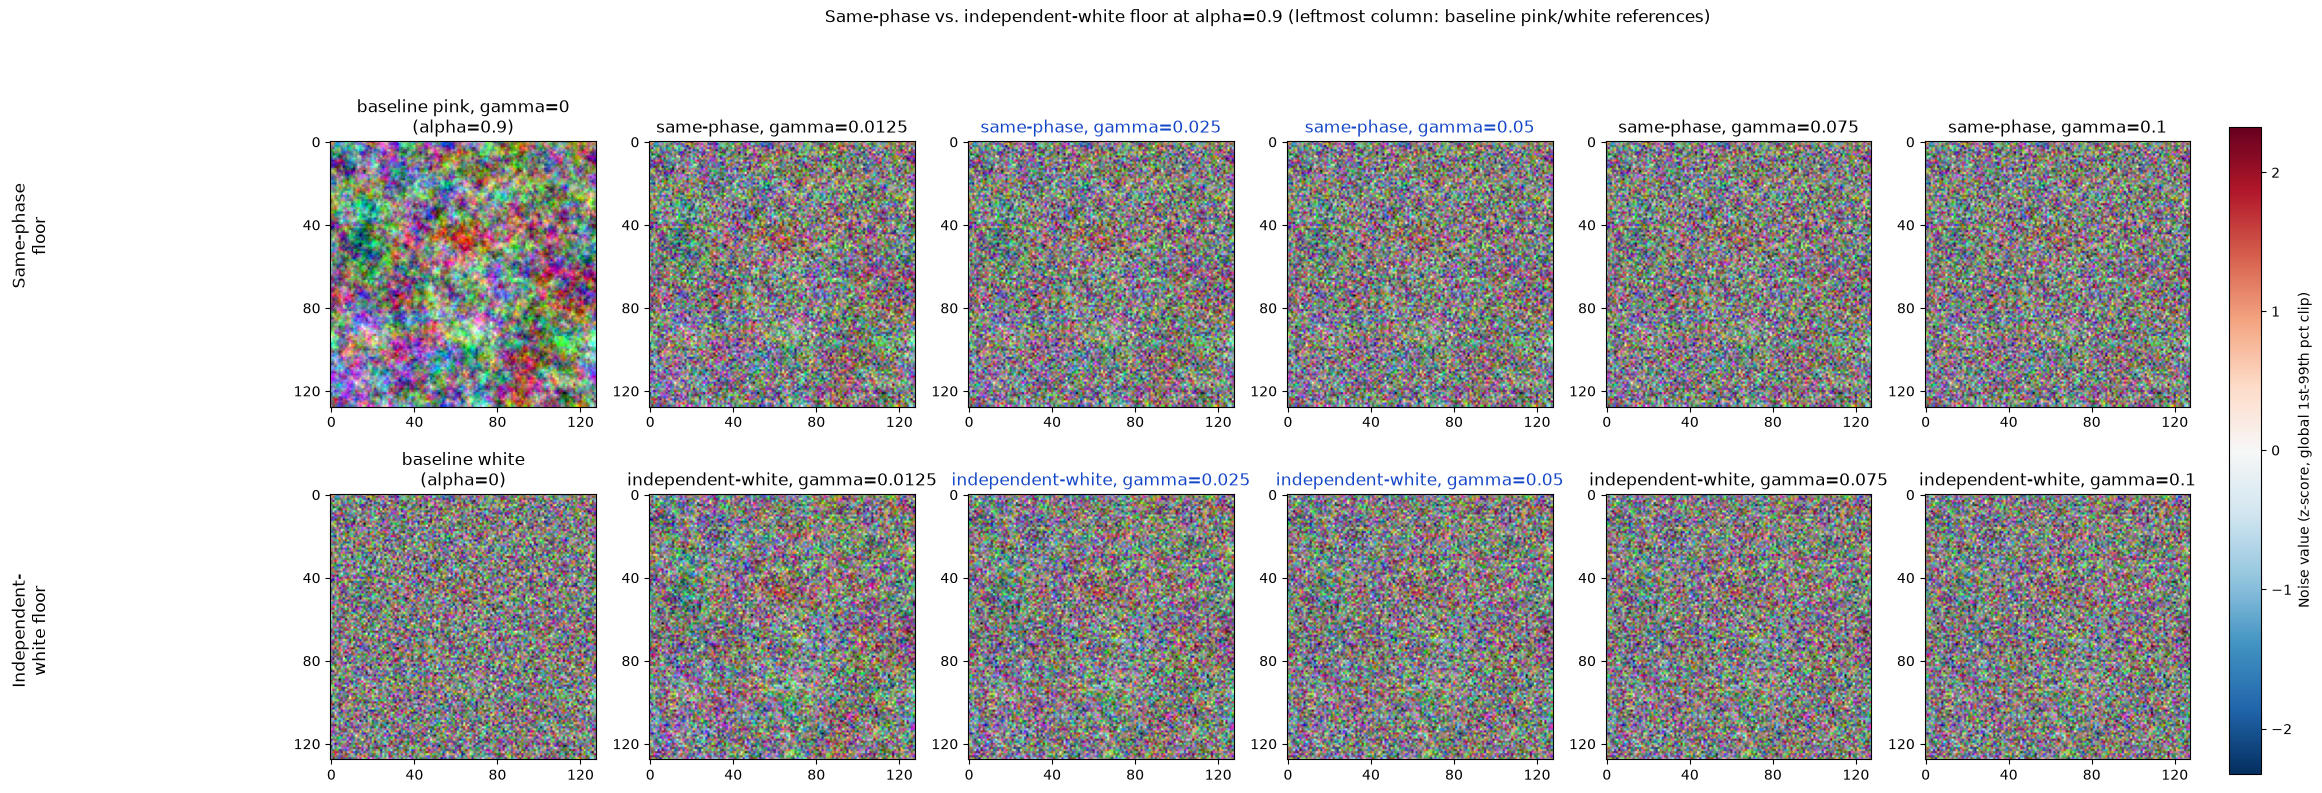

In [3]:
def to_rgb_display(tensor_chw, lo, hi):
    '''Clip the first 3 channels to a shared [lo, hi] range and rescale to [0, 1].'''
    img = tensor_chw[:3].detach().numpy().transpose(1, 2, 0)
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)


n_cols = len(GAMMAS) + 1  # +1 for the leftmost baseline reference column

all_raw = np.stack(
    [baseline_pink[0, :3].numpy(), baseline_white[0, :3].numpy()]
    + [same_phase_by_gamma[g][0, :3].numpy() for g in GAMMAS]
    + [independent_white_by_gamma[g][0, :3].numpy() for g in GAMMAS]
)
raw_lo, raw_hi = np.percentile(all_raw, 1), np.percentile(all_raw, 99)

fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols + 1, 8.4))
axes[0, 0].imshow(to_rgb_display(baseline_pink[0], raw_lo, raw_hi))
axes[0, 0].set_title(f"baseline pink, gamma=0\n(alpha={ALPHA})")
axes[1, 0].imshow(to_rgb_display(baseline_white[0], raw_lo, raw_hi))
axes[1, 0].set_title("baseline white\n(alpha=0)")
HIGHLIGHT_GAMMAS = (0.025, 0.05)  # these panels get blue titles to call them out
TITLE_BLUE = "#1446C8"  # same blue as make_comparison_grid.py::TITLE_BLUE (20, 70, 200)
for col, gamma in enumerate(GAMMAS, start=1):
    title_color = TITLE_BLUE if gamma in HIGHLIGHT_GAMMAS else "black"
    axes[0, col].imshow(to_rgb_display(same_phase_by_gamma[gamma][0], raw_lo, raw_hi))
    axes[0, col].set_title(f"same-phase, gamma={gamma}", color=title_color)
    axes[1, col].imshow(to_rgb_display(independent_white_by_gamma[gamma][0], raw_lo, raw_hi))
    axes[1, col].set_title(f"independent-white, gamma={gamma}", color=title_color)
for row in (0, 1):
    for col in range(n_cols):
        axes[row, col].set_xticks(range(0, W + 1, 40))
        axes[row, col].set_yticks(range(0, H + 1, 40))
fig.text(0.005, 0.75, "Same-phase\nfloor", va="center", ha="center", rotation="vertical", fontsize=12)
fig.text(0.005, 0.28, "Independent-\nwhite floor", va="center", ha="center", rotation="vertical", fontsize=12)
spatial_norm = mcolors.TwoSlopeNorm(vmin=raw_lo, vcenter=0.0, vmax=raw_hi)
sm = plt.cm.ScalarMappable(norm=spatial_norm, cmap="RdBu_r")
fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, label="Noise value (z-score, global 1st-99th pct clip)")
fig.suptitle(f"Same-phase vs. independent-white floor at alpha={ALPHA} (leftmost column: baseline pink/white references)", y=1.02)
plt.show()

## 2. Frequency-domain view: both methods raise the same floor shape

2D log-magnitude spectrum (DC/low frequencies centered after `fftshift`). Because both
methods share the same expected PSD, the two rows should look qualitatively similar at
matched $\gamma$ — any visible difference here is sampling noise, not a systematic effect
(section 4 shows the real, phase-based difference).

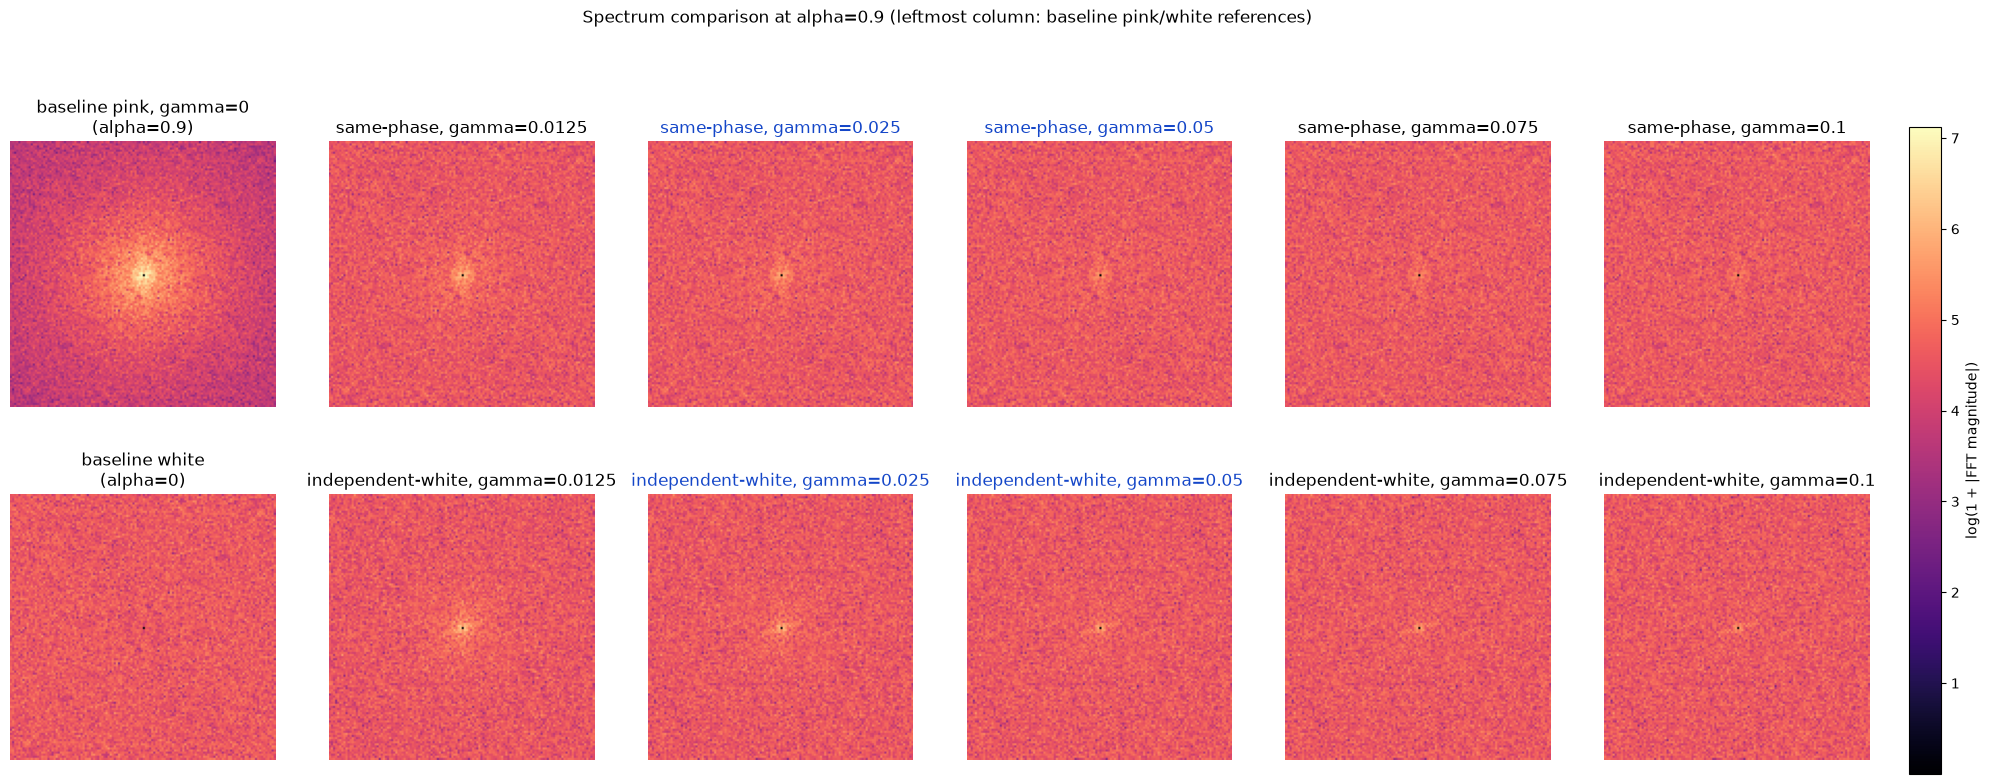

In [4]:
def log_magnitude_spectrum(tensor_chw):
    '''Channel-averaged log-magnitude 2D spectrum, shifted so DC is centered.'''
    mags = [
        np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(tensor_chw[c].numpy()))))
        for c in range(tensor_chw.shape[0])
    ]
    return np.mean(mags, axis=0)


baseline_pink_spectrum = log_magnitude_spectrum(baseline_pink[0])
baseline_white_spectrum = log_magnitude_spectrum(baseline_white[0])
same_phase_spectra = [log_magnitude_spectrum(same_phase_by_gamma[g][0]) for g in GAMMAS]
independent_white_spectra = [log_magnitude_spectrum(independent_white_by_gamma[g][0]) for g in GAMMAS]
spec_vmin = min([baseline_pink_spectrum.min(), baseline_white_spectrum.min()]
                + [s.min() for s in same_phase_spectra + independent_white_spectra])
spec_vmax = max([baseline_pink_spectrum.max(), baseline_white_spectrum.max()]
                + [s.max() for s in same_phase_spectra + independent_white_spectra])

n_cols = len(GAMMAS) + 1  # +1 for the leftmost baseline reference column
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols + 1, 8.4))
spec_im = None
axes[0, 0].imshow(baseline_pink_spectrum, cmap="magma", vmin=spec_vmin, vmax=spec_vmax)
axes[0, 0].set_title(f"baseline pink, gamma=0\n(alpha={ALPHA})")
axes[0, 0].axis("off")
axes[1, 0].imshow(baseline_white_spectrum, cmap="magma", vmin=spec_vmin, vmax=spec_vmax)
axes[1, 0].set_title("baseline white\n(alpha=0)")
axes[1, 0].axis("off")
HIGHLIGHT_GAMMAS = (0.025, 0.05)  # these panels get blue titles to call them out
TITLE_BLUE = "#1446C8"  # same blue as make_comparison_grid.py::TITLE_BLUE (20, 70, 200)
for col, gamma in enumerate(GAMMAS, start=1):
    title_color = TITLE_BLUE if gamma in HIGHLIGHT_GAMMAS else "black"
    axes[0, col].imshow(same_phase_spectra[col - 1], cmap="magma", vmin=spec_vmin, vmax=spec_vmax)
    axes[0, col].set_title(f"same-phase, gamma={gamma}", color=title_color)
    axes[0, col].axis("off")
    spec_im = axes[1, col].imshow(independent_white_spectra[col - 1], cmap="magma", vmin=spec_vmin, vmax=spec_vmax)
    axes[1, col].set_title(f"independent-white, gamma={gamma}", color=title_color)
    axes[1, col].axis("off")
fig.colorbar(spec_im, ax=axes, fraction=0.02, pad=0.02, label="log(1 + |FFT magnitude|)")
fig.suptitle(f"Spectrum comparison at alpha={ALPHA} (leftmost column: baseline pink/white references)", y=1.02)
plt.show()

## 3. Radially-averaged PSD vs. the shared theoretical curve

Both methods target $\mathrm{shape}(r) = (1 - \gamma)\, h(r)^2 + \gamma$. This plots the
empirical radial PSD of the *raw* (pre-normalization) constructions against that
theoretical shape, for a few $\gamma$ values, confirming both methods land on the same
curve.

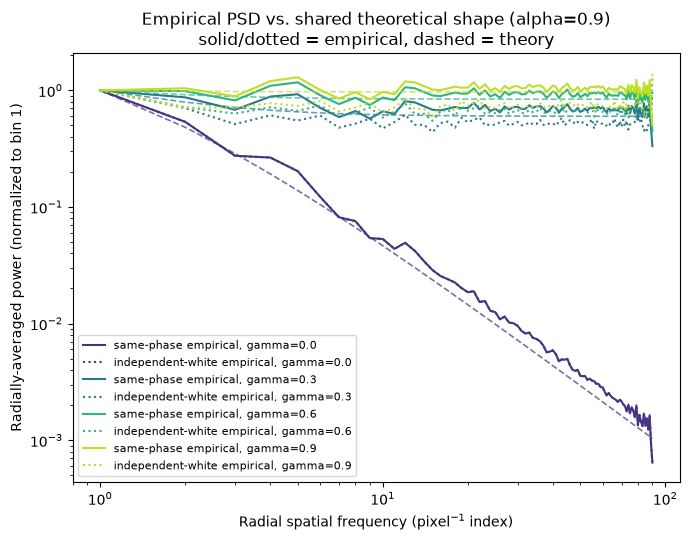

In [5]:
def radial_average(map2d):
    '''Bin a 2D map by integer pixel radius from its center and average within each bin.'''
    h, w = map2d.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2).astype(int)
    radial_sum = np.bincount(r.ravel(), weights=map2d.ravel())
    radial_count = np.bincount(r.ravel())
    return radial_sum / np.maximum(radial_count, 1)


def empirical_radial_psd(tensor_chw):
    '''Channel-averaged radial PSD profile, binned by integer pixel radius from DC.'''
    profiles = []
    for c in range(tensor_chw.shape[0]):
        img = tensor_chw[c].numpy()
        psd2d = np.abs(np.fft.fftshift(np.fft.fft2(img))) ** 2
        profiles.append(radial_average(psd2d))
    return np.mean(profiles, axis=0)


def theoretical_shape(n_bins, alpha, gamma):
    '''shape(r) = (1 - gamma) * h(r)^2 + gamma, h(r) = (1+r)^-alpha -- the closed-form
    target both methods are built to match (see noise_validation.py::theoretical_shell_curve).'''
    r = np.arange(n_bins)
    h = (1.0 + r) ** (-alpha)
    return (1.0 - gamma) * h ** 2 + gamma


PSD_GAMMAS = [0.0, 0.3, 0.6, 0.9]
raw_same_phase = {g: same_phase_floor(base_white, ALPHA, g) for g in PSD_GAMMAS}
raw_independent_white = {g: independent_white(base_white, eta, ALPHA, g) for g in PSD_GAMMAS}

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(PSD_GAMMAS)))
for gamma, color in zip(PSD_GAMMAS, colors):
    empirical = empirical_radial_psd(raw_same_phase[gamma][0])
    theory = theoretical_shape(len(empirical), ALPHA, gamma)
    freq_index = np.arange(1, len(empirical))  # skip DC (index 0) on the log-log plot
    # Normalize both curves by their own value at the first non-DC bin so shape (not
    # absolute scale) is what's compared, matching the "shape only" theoretical claim.
    ax.loglog(freq_index, empirical[1:] / empirical[1], color=color, linestyle="-",
               label=f"same-phase empirical, gamma={gamma}")
    ax.loglog(freq_index, theory[1:] / theory[1], color=color, linestyle="--", linewidth=1.2, alpha=0.7)

    empirical_iw = empirical_radial_psd(raw_independent_white[gamma][0])
    ax.loglog(freq_index, empirical_iw[1:] / empirical_iw[1], color=color, linestyle=":",
               label=f"independent-white empirical, gamma={gamma}")

ax.set_xlabel("Radial spatial frequency (pixel$^{-1}$ index)")
ax.set_ylabel("Radially-averaged power (normalized to bin 1)")
ax.set_title(f"Empirical PSD vs. shared theoretical shape (alpha={ALPHA})\nsolid/dotted = empirical, dashed = theory")
ax.legend(fontsize=8, ncol=1, loc="lower left")
fig.tight_layout()
plt.show()

## 4. Phase coherence: the real difference between the two methods

Both methods match the same PSD, so the plots above should look similar at matched
$\gamma$. The actual distinguishing property is how correlated each method's output stays
with the pure pink reference ($\gamma=0$) as $\gamma$ increases.

For **independent-white**,
$z = \sqrt{1-\gamma}\, z_{\text{pink}} + \sqrt{\gamma}\, \eta$
is a linear mixture of $z_{\text{pink}}$ (raw variance $\sigma_x^2$, generally $< 1$ since
the pink filter attenuates high frequencies) and an uncorrelated unit-variance $\eta$, so
the Pearson correlation with $z_{\text{pink}}$ has the closed form

$$
\operatorname{corr}\big(z,\, z_{\text{pink}}\big)
= \frac{\sqrt{1-\gamma}\;\sigma_x}{\sqrt{(1-\gamma)\,\sigma_x^2 + \gamma}}
$$

— this is checked against the empirical value below.

For **same-phase**, the floor is applied as a *spectral reweighting* of the same phase,
not a spatial mixture, so no such simple closed form applies — its empirical correlation
curve is shown for direct comparison instead.

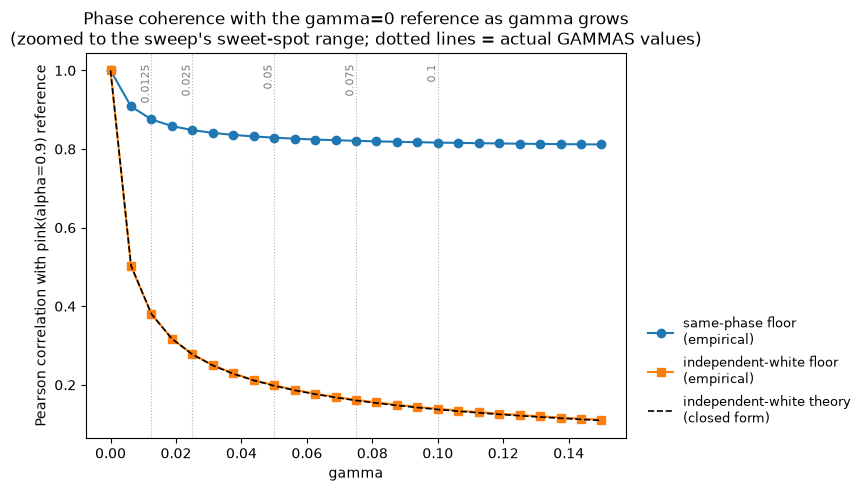

Max |empirical - theory| gap for independent-white correlation: 0.0018
independent-white correlation matches the closed-form mixture-correlation curve.


In [6]:
def pearson_corr(a, b):
    '''Per-sample/channel Pearson correlation, averaged across batch and channels.'''
    a = a.reshape(a.shape[0], a.shape[1], -1)
    b = b.reshape(b.shape[0], b.shape[1], -1)
    a = a - a.mean(dim=-1, keepdim=True)
    b = b - b.mean(dim=-1, keepdim=True)
    numerator = (a * b).sum(dim=-1)
    denominator = torch.sqrt((a ** 2).sum(dim=-1) * (b ** 2).sum(dim=-1)) + 1e-8
    return (numerator / denominator).mean().item()


gamma_grid = np.linspace(0.0, max(GAMMAS) * 1.5, 25)  # zoomed to the experiment's actual gamma sweet-spot range
reference = pink(base_white, ALPHA)  # raw (pre-normalization) gamma=0 reference
sigma_x = reference.std(unbiased=False).item()  # pink's own raw std (< 1: the filter attenuates high frequencies)

corr_same_phase = [pearson_corr(same_phase_floor(base_white, ALPHA, g), reference) for g in gamma_grid]
corr_independent_white = [pearson_corr(independent_white(base_white, eta, ALPHA, g), reference) for g in gamma_grid]
corr_independent_white_theory = (np.sqrt(1.0 - gamma_grid) * sigma_x
                                  / np.sqrt((1.0 - gamma_grid) * sigma_x ** 2 + gamma_grid))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gamma_grid, corr_same_phase, "o-", label="same-phase floor\n(empirical)")
ax.plot(gamma_grid, corr_independent_white, "s-", label="independent-white floor\n(empirical)")
ax.plot(gamma_grid, corr_independent_white_theory, "k--", linewidth=1.2, label="independent-white theory\n(closed form)")
for g in GAMMAS:
    ax.axvline(g, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.text(g, 0.97, f"{g}", color="gray", fontsize=8, ha="right", va="top", rotation=90,
            transform=ax.get_xaxis_transform())
ax.set_xlabel("gamma")
ax.set_ylabel(f"Pearson correlation with pink(alpha={ALPHA}) reference")
ax.set_title("Phase coherence with the gamma=0 reference as gamma grows\n(zoomed to the sweep's sweet-spot range; dotted lines = actual GAMMAS values)")
ax.legend(fontsize=9, loc="lower left", bbox_to_anchor=(1.02, 0.0), frameon=False)
fig.subplots_adjust(right=0.8)
plt.show()

max_theory_gap = float(np.max(np.abs(np.array(corr_independent_white) - corr_independent_white_theory)))
print(f"Max |empirical - theory| gap for independent-white correlation: {max_theory_gap:.4f}")
assert max_theory_gap < 0.05, "independent-white correlation should track the closed-form curve closely"
print("independent-white correlation matches the closed-form mixture-correlation curve.")

## 5. Sanity check against a real cached noise batch

Point `NOISE_CACHE_DIR` at any `outputs/<run_id>/noise_cache/p*_s*` folder produced by
`run_experiment.py` (via `noise_methods.py::cache_noise_batch`) -- it contains
`base_white.pt` and `independent_eta.pt` for one prompt/seed block. This reconstructs
both proposed methods from the *real* cached tensors using the exact same functions
defined above, so a run's actual noise can be inspected directly.

Loaded cache: base_white (4, 4, 64, 64), independent_eta (4, 4, 64, 64)


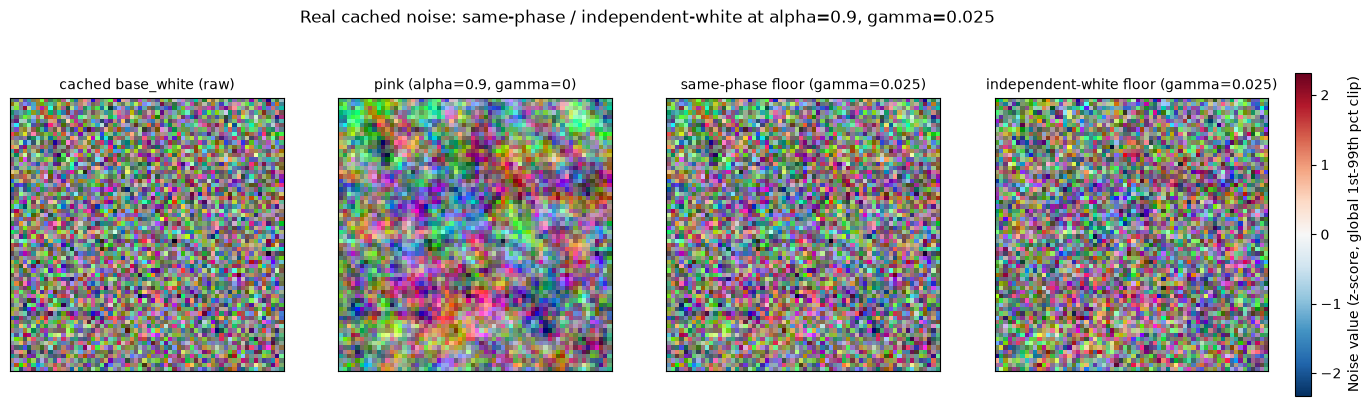

In [7]:
from pathlib import Path

# Edit this to any run's noise_cache/p*_s* folder, e.g. one produced by:
#   python3 run_experiment.py --config configs/flux2_klein_full.yaml --stage generate --run-id <run_id>
NOISE_CACHE_DIR = Path("../noise_init/outputs/sdxl_turbo_full_finer/noise_cache/p000_s001")
CACHE_ALPHA, CACHE_GAMMA = 0.9, 0.025  # alpha/gamma used to sample our two proposed methods below
BASELINE_ALPHA = 0.9  # alpha for the baseline pink reference only, free to differ from CACHE_ALPHA
CACHE_SAMPLE_INDEX = 0     # which batch element to visualize
CACHE_CHANNELS = (0, 1, 2)  # which latent channels to show as pseudo-RGB (real caches have many more than 3)

cached_base_white = torch.load(NOISE_CACHE_DIR / "base_white.pt", map_location="cpu", weights_only=True)
cached_eta = torch.load(NOISE_CACHE_DIR / "independent_eta.pt", map_location="cpu", weights_only=True)
print(f"Loaded cache: base_white {tuple(cached_base_white.shape)}, independent_eta {tuple(cached_eta.shape)}")

cached_pink = normalize(pink(cached_base_white, BASELINE_ALPHA))
cached_same_phase = normalize(same_phase_floor(cached_base_white, CACHE_ALPHA, CACHE_GAMMA))
cached_independent_white = normalize(independent_white(cached_base_white, cached_eta, CACHE_ALPHA, CACHE_GAMMA))

cache_panels = {
    "cached base_white (raw)": cached_base_white[CACHE_SAMPLE_INDEX, list(CACHE_CHANNELS)],
    f"pink (alpha={BASELINE_ALPHA}, gamma=0)": cached_pink[CACHE_SAMPLE_INDEX, list(CACHE_CHANNELS)],
    f"same-phase floor (gamma={CACHE_GAMMA})": cached_same_phase[CACHE_SAMPLE_INDEX, list(CACHE_CHANNELS)],
    f"independent-white floor (gamma={CACHE_GAMMA})": cached_independent_white[CACHE_SAMPLE_INDEX, list(CACHE_CHANNELS)],
}

cache_raw = np.stack([t.numpy() for t in cache_panels.values()])
cache_lo, cache_hi = np.percentile(cache_raw, 1), np.percentile(cache_raw, 99)

fig, axes = plt.subplots(1, len(cache_panels), figsize=(4 * len(cache_panels) + 1, 4.2))
for ax, (title, tensor) in zip(axes, cache_panels.items()):
    ax.imshow(to_rgb_display(tensor, cache_lo, cache_hi))
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
cache_norm = mcolors.TwoSlopeNorm(vmin=cache_lo, vcenter=0.0, vmax=cache_hi)
sm = plt.cm.ScalarMappable(norm=cache_norm, cmap="RdBu_r")
fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, label="Noise value (z-score, global 1st-99th pct clip)")
fig.suptitle(f"Real cached noise: same-phase / independent-white at alpha={CACHE_ALPHA}, gamma={CACHE_GAMMA}", y=1.03)
plt.show()